---
embed-resources: true
echo: false
warning: false
message: false
---

# Predicting House Prices Using Machine Learning 

## Introduction

The goal of this report is to describe the methods and results of a regression model that seeks to estimate the value of homes given various data. This will be done using data on house size, attributes, qualities, the house lot and more. This can serve as an alternative model to Zillow, and can serve to provide instant price estimates to buyers and sellers, help homeowners track property values over time and democratize access to market information.

This will use data about homes in Ames, Iowa that sold between 2006 and 2010, but can be easily replicated for different housing markets in different time periods. To accomplish this, a Histogram Gradient Boosting Regressor model will be used along with various preprocessing techniques.

## Methods

In [41]:
# imports

# Data Processing / Visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pprint

# ML Preprocessing
from sklearn.preprocessing import (RobustScaler, OneHotEncoder, StandardScaler)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Modeling, Evaluation
from sklearn.model_selection import (GridSearchCV, KFold)
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.inspection import DecisionBoundaryDisplay
from joblib import dump
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.ensemble import HistGradientBoostingRegressor as hist
from sklearn.model_selection import GridSearchCV as gs


For this report and its associated model, Pandas and NumPy will be used for data handling, Seaborn and Matplotlib will be used for visualization. Sklearn modules will be used for preprocessing and making the data suitable for machine learning, and also evaluating and visualizing outcomes. A Histogram Gradient Boosting Regressor model will be used to make predictions, which stacks weaker models on top of each other after binning data to come up with a more effective estimator.

### Data

This dataset, originally sourced from the Journal of Statistics Education via Kaggle, is a standard dataset in the machine learning community. The data will be split into training and testing datasets.

In [20]:
housing_train = pd.read_parquet(
    "https://lab.cs307.org/housing/data/housing-train.parquet",
)
housing_test = pd.read_parquet(
    "https://lab.cs307.org/housing/data/housing-test.parquet",
)

### Data Dictionary

* SalePrice: [int64] Sale price in USD.

* Order:[int64] Observation number.

* PID [int64]: Parcel identification number - can be used with city web site for parcel review.

* MS SubClass: [int64] Identifies the type of dwelling involved in the sale.

* MS Zoning: [object] Identifies the general zoning classification of the sale.

* Lot Frontage: [float64] Linear feet of street connected to property.

* Lot Area: [int64] Lot size in square feet.

* Street: [object] Type of road access to property.

* Alley: [object] Type of alley access to property.

* Lot Shape: [object] General shape of property.

* Land Contour: [object] Flatness of the property.

* Utilities: [object] Type of utilities available.

* Lot Config: [object] Lot configuration.

* Land Slope: [object] Slope of property.

* Neighborhood: [object] Physical locations within Ames city limits (map available).

* Condition 1: [object] Proximity to various conditions.

* Condition 2: [object] Proximity to various conditions (if more than one is present).

* Bldg Type: [object] Type of dwelling.

* House Style:[object] Style of dwelling.

* Overall Qual: [int64] Rates the overall material and finish of the house.

* Overall Cond: [int64] Rates the overall condition of the house.

* Year Built: [int64] Original construction date.

* Year Remod/Add: [int64] Remodel date (same as construction date if no remodeling or additions).

* Roof Style: [object] Type of roof.

* Roof Matl: [object] Roof material.

* Exterior 1st: [object] Exterior covering on house.

* Exterior 2nd: [object] Exterior covering on house (if more than one material).

* Mas Vnr Type: [object] Masonry veneer type.

* Mas Vnr Area: [float64] Masonry veneer area in square feet.

* Exter Qual: [object] Evaluates the quality of the material on the exterior.

* Exter Cond: [object] Evaluates the present condition of the material on the exterior.

* Foundation: [object] Type of foundation.

* Bsmt Qual: [object] Evaluates the height of the basement.

* Bsmt Cond: [object] Evaluates the general condition of the basement.

* Bsmt Exposure: [object] Refers to walkout or garden level walls.

* BsmtFin Type 1: [object] Rating of basement finished area.

* BsmtFin SF 1: [float64] Type 1 finished square feet.

* BsmtFin Type 2: [object] Rating of basement finished area (if multiple types).

* BsmtFin SF 2: [float64] Type 2 finished square feet.

* Bsmt Unf SF: [float64] Unfinished square feet of basement area.

* Total Bsmt SF:[float64] Total square feet of basement area.

* Heating: [object] Type of heating.

* Heating QC: [object] Heating quality and condition.

* Central Air: [object] Central air conditioning.

* Electrical: [object] Electrical system.

* 1st Flr SF: [int64] First Floor square feet.

* 2nd Flr SF: [int64] Second floor square feet.

* Low Qual Fin SF: [int64] Low quality finished square feet (all floors).

* Gr Liv Area: [int64] Above grade (ground) living area square feet.

* Bsmt Full Bath: [float64] Basement full bathrooms.

* Bsmt Half Bath: [float64] Basement half bathrooms.

* Full Bath: [int64] Full bathrooms above grade.

* Half Bath: [int64] Half baths above grade.

* Bedroom AbvGr: [int64] Bedrooms above grade (does not include basement bedrooms).

* Kitchen AbvGr: [int64] Kitchens above grade.

* Kitchen Qual: [object] Kitchen quality.

* TotRms AbvGrd: [int64] Total rooms above grade (does not include bathrooms).

* Functional: [object] Home functionality (Assume typical unless deductions are warranted).

* Fireplaces: [int64] Number of fireplaces.

* Fireplace Qu: [object] Fireplace quality.

* Garage Type: [object] Garage location.

* Garage Yr Blt: [float64] Year garage was built.

* Garage Finish: [object] Interior finish of the garage.

* Garage Cars: [float64] Size of garage in car capacity.

* Garage Area: [float64] Size of garage in square feet.

* Garage Qual: [object] Garage quality.

* Garage Cond: [object] Garage condition.

* Paved Drive: [object] Paved driveway.

* Wood Deck SF: [int64] Wood deck area in square feet.

* Open Porch SF: [int64] Open porch area in square feet.

* Enclosed Porch:[int64] Enclosed porch area in square feet.

* 3Ssn Porch: [int64] Three season porch area in square feet.

* Screen Porch: [int64] Screen porch area in square feet.

* Pool Area: [int64] Pool area in square feet.

* Pool QC: [object] Pool quality.

* Fence: [object] Fence quality.

* Misc Feature: [object] Miscellaneous feature not covered in other categories.

* Misc Val: [int64] Value of miscellaneous feature.

* Mo Sold: [int64] Month Sold (MM).

* Yr Sold: [int64] Year Sold (YYYY).

* Sale Type: [object] Type of sale.

* Sale Condition: [object] Condition of sale.

In [21]:
samples = len(housing_train)
features = housing_train.shape[1]-1
print(f"Samples: {samples}, Features: {features}")

Samples: 1875, Features: 81


Our training dataset has 1875 samples and 81 features. Each sample represents an individual house, and has 81 datapoints to describe it. These 81 features are what we will use to predict the target variable (sale price).

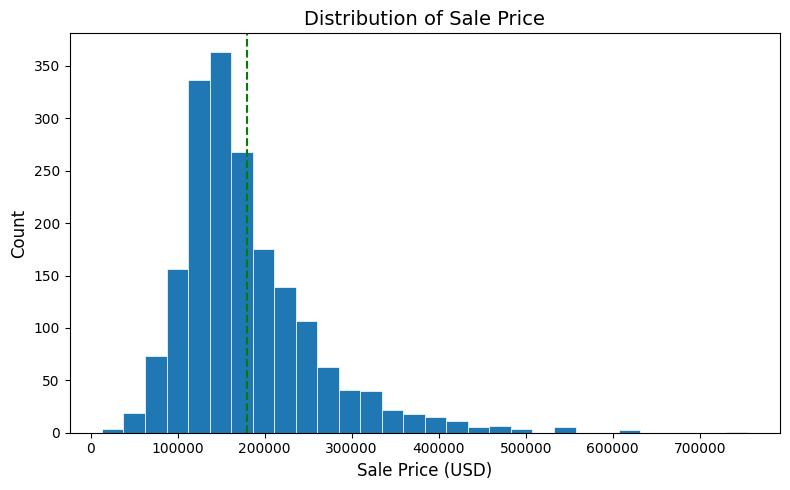

In [42]:
#| fig-cap: "Training Data Sale Price Distribution"

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(housing_train['SalePrice'], bins=30, edgecolor="white", linewidth=0.5)

ax.set_xlabel("Sale Price (USD)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Distribution of Sale Price", fontsize=14)
ax.axvline(housing_train['SalePrice'].mean(), linestyle='--', zorder=1, color='g')
plt.tight_layout()
plt.show()

In [23]:
print(f"Mean: ${housing_train['SalePrice'].mean()}, SD: ${housing_train['SalePrice'].std()}")

Mean: $179765.09333333332, SD: $78887.3286990061


Above we can observe the distribution of sale prices for homes in the training dataset. It is a right-tail distribution with a center/mean of ~$180,000 and a standard deviation of ~$79,000.

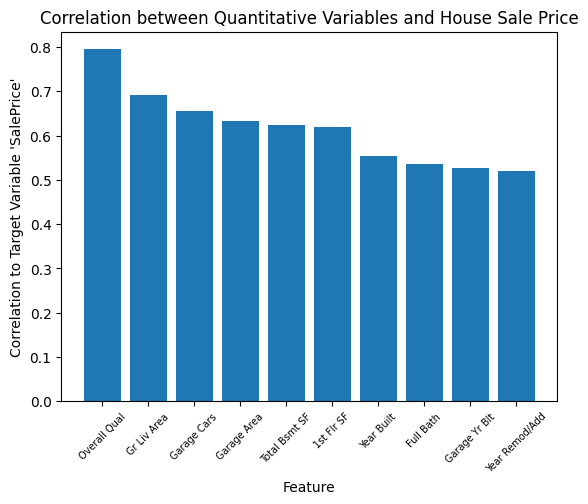

In [43]:
#| fig-cap: "Strongest Quantitative Feature Correlations to Sale Price"

qual_df_corr = housing_train[housing_train.select_dtypes(include=['int64', 'float64']).dtypes.index].corr()
graph_corr = qual_df_corr['SalePrice'].sort_values(ascending=False)[1:11]
plt.bar(graph_corr.index, graph_corr.values)
plt.xticks(rotation=45, size=7)
plt.title("Correlation between Quantitative Variables and House Sale Price")
plt.xlabel("Feature")
plt.ylabel("Correlation to Target Variable 'SalePrice'")
plt.show()

Moving on to how features correlate with the SalePrice target variable, several features have > 0.5 correlation, with overall quality, square footage, and garage space being most strongly correlated with the final sale price of the home. These features will likely be the most useful in formulating predictions for the model.

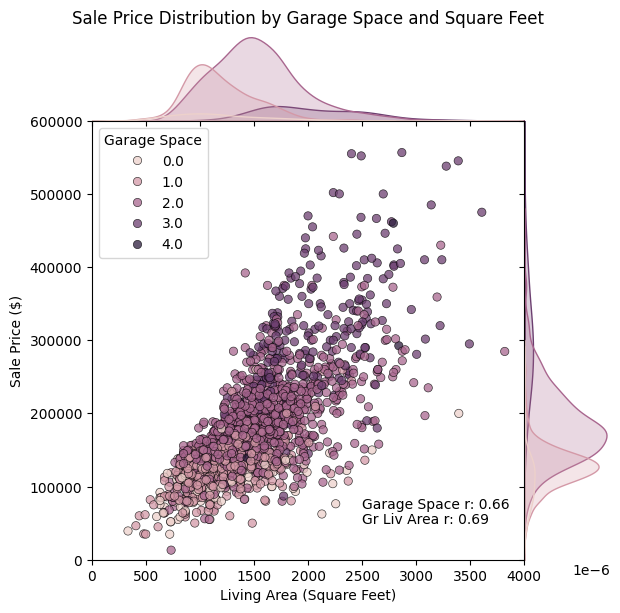

In [25]:
#| fig-cap: "Sale Price Distribution by Garage Space and Square Feet"
plot = sns.jointplot(
    data=housing_train,
    x="Gr Liv Area",
    y="SalePrice",
    hue="Garage Cars",
    edgecolor="k",
    alpha=0.75,
    space=0,
)
plot.set_axis_labels(
    xlabel="Living Area (Square Feet)",
    ylabel="Sale Price ($)",
)
plot.ax_joint.legend(
    title="Garage Space",
    loc="upper left",
)
plt.title("Sale Price Distribution by Garage Space and Square Feet", pad=70)
plt.text(2500, 70000, f"Garage Space r: {round(qual_df_corr['SalePrice']['Garage Cars'],2)}")
plt.text(2500, 50000, f"Gr Liv Area r: {round(qual_df_corr['SalePrice']['Gr Liv Area'],2)}")
plt.xlim(0, 4000)
plt.ylim(0, 600000)
plt.show()

This shows how the relationship between living area and square feet interact with garage space. Both of these features are strongly correlated with 'SalePrice', with correlations of 0.66 for garage space and 0.69 for living area. A clear positive relationship for both features can be seen in the chart, with increases in garage space amplifying the value of high square footage homes. 

### Models

In [26]:
X_train = housing_train.drop("SalePrice", axis=1)
y_train = housing_train["SalePrice"]

X_test = housing_test.drop("SalePrice", axis=1)
y_test = housing_test["SalePrice"]

The data is split into what we're trying to predict (target variable) and what we're using to predict it (feature variables). We do this for both the data we're training the model on and the data we're testing our final model on.

In [27]:
quant_cols = housing_train[housing_train.select_dtypes(include=['int64', 'float64']).dtypes.index].columns
qual_cols = housing_train.columns.drop(quant_cols).tolist()
quant_cols = quant_cols.drop('SalePrice').tolist()

numeric_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("OneHotEncoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ] 
)

preprocessor = ColumnTransformer(
    [
        ("numeric", numeric_transformer, quant_cols),
        ("categorical", categorical_transformer, qual_cols)    
    ],
    remainder='drop'
)
pipe = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("regressor", hist(random_state=7))
    ]
)

This creates a procedure to preprocess the independent variable (feature) data before we put it into the model. There is a different procedure depending on whether the data is categorical (neighborhood, building type and 41 others) or numerical (living area, garage space and 36 others). These two procedures are combined to make an overall process for cleaning up the data. 

There are a few significant operations being performed on the data. The first one is filling in missing values (imputing). For numerical data, we are just plugging in the median value of the associated variable, but for categorical data, we are plugging in the most frequent. The second operation is scaling. Different variables have different standard deviations, so for numerical variables we scale them, so the mean is 0 and the standard deviation is 1. This ensures that a variable won't have an outsized impact on the model due to the nature of its variance. We also encode the categorical data, assigning 0s and 1s depending on the value, making it numerically processable. 

Finally, we assign what process we want done to what columns, separating categorical and numerical data and assigning it to each process. We then combine this preprocessor with the type of regressor model we want to use (Histogram Gradient Boosting Regressor) to create an overall pipeline for our model.

In [28]:
params = {
    "regressor__learning_rate": [0.05],
    "regressor__max_iter": [400, 600],
    "regressor__max_depth": [2, 4],
    "regressor__max_features": [0.1, 0.3],
    "regressor__min_samples_leaf": [5, 10],
}

model = gs(pipe, param_grid=params, cv=5, scoring='neg_mean_absolute_percentage_error', verbose=0, n_jobs=-1)
model.fit(X_train, y_train)


Next, we select a range of parameters we want to test on for our model. This includes the learning rate (how much each new data point influences the model), max iterations (how many tries the model gets before stopping), max depth (how deep the decision tree can go), max features (how many features can be considered at each split), and minimum samples for each leaf.

Then, we will try making a model with every possible combination of the metrics we give it, within the range we give it, and have it return the one with the best mean absolute percentage error. This is the most suitable metric for this scenario because we are predicting continuous data and want to prioritize how close the average guess is to the true value.

We chose 1 potential value for learning rate, 2 potential values for max iterations, 2 potential values for max depth, 2 potential values for max features, and 2 potential values for minimum samples for each leaf. This results in 1 x 2 x 2 x 2 x 2 = 16 candidate models. For each given candidate combination, they are evaluated by splitting training data into fifths. A fifth of the inputted train data is held aside for scoring, and the model is trained on the other four fifths, rotating until all five fifths have been used for scoring. The parameter combination resulting in the highest average score across these five validation fits is returned as the model. This is cross-validation. In all, this means that 80 (16 combinations x 5 folds) models will be fitted in pursuit of tuning for the best parameters.

More parameters involving regularization and others were considered but to train the model quickly, only a few parameters and potential values were tuned.

## Results

In [29]:
model.best_params_

{'regressor__learning_rate': 0.05,
 'regressor__max_depth': 4,
 'regressor__max_features': 0.3,
 'regressor__max_iter': 600,
 'regressor__min_samples_leaf': 10}

The parameters of the best combination were as follows:
* Learning Rate: 0.05
* Max Depth: 4
* Max Features: 0.3, meaning only 30% of features are chosen at each split
* Max Iterations: 600
* Minimum Samples: 10

In [30]:
def proportion_within_threshold(y_true, y_pred, threshold=0.20):
    return np.mean((np.abs(y_pred - y_true) / y_true) <= threshold)

In [31]:
train_prop = proportion_within_threshold(y_train, model.predict(X_train))
test_prop = proportion_within_threshold(y_test, model.predict(X_test))
train_mape = MAPE(y_train, model.predict(X_train))
test_mape = MAPE(y_test, model.predict(X_test))
print(f"Train proportion within 20%: {round(train_prop, 2)}, test proportion within 20%: {round(test_prop, 3)}")
print(f"Train MAPE: {round(train_mape*100, 2)}%, test MAPE: {round(test_mape*100,2)}%")

Train proportion within 20%: 0.99, test proportion within 20%: 0.934
Train MAPE: 3.88%, test MAPE: 7.99%


The model with these combinations was within 20% of the true value 93.4% of the time when predicting on unseen data, and has a mean absolute percentage error of 7.99%

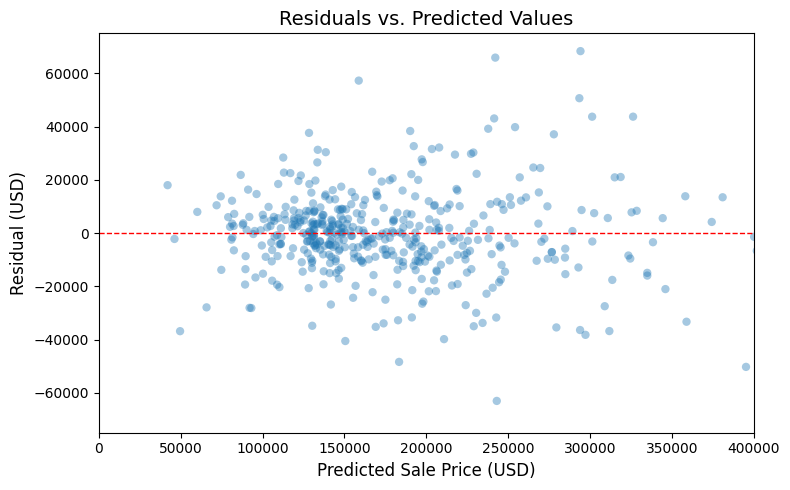

Worst Underestimates: [208827.70320373 151269.4219097  127797.27343713 122898.18068277
 106537.96629621]
Worst Overestimates: [ -48401.23305895  -50275.96648879  -53077.57050968  -63055.49251633
 -184134.70182708]
Average Residual: $794
Of 469 predictions on unseen data, only 10 were off by 30%+


In [40]:
#| fig-cap: "Residuals vs. Predicted Values for Housing Sale Price Model"


y_pred = model.predict(X_test)
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(y_pred, residuals, alpha=0.4, edgecolors="none")
ax.axhline(0, color="red", linewidth=1, linestyle="--")

ax.set_xlabel("Predicted Sale Price (USD)", fontsize=12)
ax.set_ylabel("Residual (USD)", fontsize=12)
ax.set_title("Residuals vs. Predicted Values", fontsize=14)


plt.xlim(0, 400000)
plt.ylim(-75000, 75000)
plt.tight_layout()
plt.show()
print(f"Worst Underestimates: {residuals.sort_values(ascending=False)[:5].values}")
print(f"Worst Overestimates: {residuals.sort_values(ascending=False)[-5:].values}")
print(f"Average Residual: ${round(residuals.mean())}")
rel_residuals = np.abs(residuals)/y_pred
print(f'Of {len(housing_test)} predictions on unseen data, only {len(rel_residuals[rel_residuals.values > 0.3])} were off by 30%+')


This graph shows how wrong the model was when predicting the sale price for every data point in the unseen testing dataset. On average, the model underestimated by $794. The mean absolute percentage error is 7.99%. There are no clear shapes in this data, although the residuals tend to get larger the more expensive the house gets. This graph was cropped for clarity, and the biggest mispredictions are above, with 6 being off by $100,000+.  

Now we serialize the model to make it shareable.

In [33]:
dump(model, "housing.joblib", compress=3)

['housing.joblib']

## Discussion

For the purpose of creating a house price estimator for a real estate listing aggregator that can compete with Zillow, this is a fairly effective model. When tested on unseen data, it had a mean absolute percentage error just below 8% and 93.4% of estimates were within 20% of the true value. Residuals showed no clear pattern, and although there were some residuals that were very large (above $100,000), this must be put in context of what prediction error means here. A $100,000 prediction error on a $1,000,000 home is not as bad as a $80,000 error on a $200,000 home. On unseen testing data, only 10 of 469 predictions were off by 30% or more. These errors could be due to factors not captured by data in the model such as bidding dynamics and other idiosyncratic factors. This model would be a very helpful resource for homeowners to estimate the price they could fetch for their home on the market without going through an intensive valuation process. 

Despite the strong results of the model, there are a few limitations. First, the model was trained on data for homes in Ames, Iowa several years ago. Although it performed well on unseen data that was held back at the start, using this model to estimate the value of new homes in different areas would likely drastically undershoot the true value. To be deployed at scale, this model would need newer data that covers the geographic scale it would be used in. For example, if the company deploying this wanted to have a select launch in Illinois, they could start with obtaining comprehensive Illinois housing data with sale prices and refitting the models. Additionally, the model is trained on 81 features, which is a steep data requirement for someone trying to conveniently estimate the price of their home.

The mechanics of the model are sound, using a Histogram Gradient Boosting Regressor is a flexible model that is appropriate to use in this context, and the tuned parameters would likely hold up if the model were refit on newer, broader data. The regularization of using the selected values for max depth, learning rate and max features would likely persist in effectiveness with new inputs. These parameters were optimized for the bias variance tradeoff, and this is a property of the model architecture rather than the data it is used on. A version could determine what features would be most important to keep, especially because there is significant multicollinearity in the data. A production version could have reduced feature inputs.

I would **recommend deploying this model** after being refit with up to date and geographically comprehensive data.